# Transcriptional fidelity of patient-derived models in colorectal signet-ring cell carcinoma

### Independent re-analysis of public RNA-sequencing data from GSE279979

**Question:** Which transcriptional programmes distinguish colorectal signet-ring cell carcinoma from adjacent normal tissue, and to what extent are these tumour-associated programmes preserved in patient-derived xenograft models?

Because the public RNA-seq cohort contains only two samples per group, this analysis is exploratory and focuses on transcriptional patterns and pathway-level concordance rather than definitive biomarker discovery.

In [1]:
!pip install -q pydeseq2 gseapy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.7/689.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.2/190.2 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.9/376.9 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 5.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the

In [2]:
!pip install -q pandas==2.2.3 pydeseq2 gseapy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 11.8 MB/s eta 0:00:00


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("pandas:", pd.__version__)
print("Setup working")

pandas: 2.2.3
Setup working


In [2]:
!wget -q \
"https://ftp.ncbi.nlm.nih.gov/geo/series/GSE279nnn/GSE279979/suppl/GSE279979_raw_counts.txt.gz" \
-O SRCC_raw_counts.txt.gz

print("Downloaded")

Downloaded


In [3]:
counts_raw = pd.read_csv(
    "SRCC_raw_counts.txt.gz",
    sep="\t"
)

print("Shape:", counts_raw.shape)

display(counts_raw.head())

print("\nColumns:")
print(counts_raw.columns.tolist())

Shape: (62703, 12)


,Geneid,Chr,Start,End,Strand,Length,N_1,N_2,T_1,T_2,UT_1,UT_2
0,ENSG00000290825.1,chr1;chr1;chr1,11869;12613;13221,12227;12721;14409,+;+;+,1657,0,0,0,0,0,0
1,ENSG00000223972.6,chr1;chr1;chr1;chr1;chr1;chr1,12010;12179;12613;12975;13221;13453,12057;12227;12697;13052;13374;13670,+;+;+;+;+;+,632,0,0,0,0,0,0
2,ENSG00000227232.5,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;c...,14404;15005;15796;16607;16858;17233;17606;1791...,14501;15038;15947;16765;17055;17368;17742;1806...,-;-;-;-;-;-;-;-;-;-;-,1351,17,37,28,27,25,22
3,ENSG00000278267.1,chr1,17369,17436,-,68,0,0,1,1,0,0
4,ENSG00000243485.5,chr1;chr1;chr1;chr1;chr1,29554;30267;30564;30976;30976,30039;30667;30667;31109;31097,+;+;+;+;+,1021,0,0,0,0,0,1



Columns:
['Geneid', 'Chr', 'Start', 'End', 'Strand', 'Length', 'N_1', 'N_2', 'T_1', 'T_2', 'UT_1', 'UT_2']


## 1. Count matrix and sample structure

The processed featureCounts matrix contains two adjacent-normal samples, two primary SRCC tumour samples, and two patient-derived xenograft (PDX) samples.

The analysis asks two questions:

1. Which transcriptional programmes distinguish primary SRCC from adjacent normal tissue?
2. To what extent are those tumour-associated programmes preserved in PDX models?

In [4]:
sample_cols = ["N_1", "N_2", "T_1", "T_2", "UT_1", "UT_2"]

counts = counts_raw[
    ["Geneid"] + sample_cols
].copy()

# Remove Ensembl version suffix, e.g. ENSG000001234.5 -> ENSG000001234
counts["Geneid"] = counts["Geneid"].str.split(".").str[0]

counts = counts.set_index("Geneid")

print("Count matrix:", counts.shape)
display(counts.head())

Count matrix: (62703, 6)


,N_1,N_2,T_1,T_2,UT_1,UT_2
Geneid,,,,,,
ENSG00000290825,0,0,0,0,0,0
ENSG00000223972,0,0,0,0,0,0
ENSG00000227232,17,37,28,27,25,22
ENSG00000278267,0,0,1,1,0,0
ENSG00000243485,0,0,0,0,0,1


In [5]:
sample_metadata = pd.DataFrame(
    {
        "condition": [
            "Normal",
            "Normal",
            "Tumor",
            "Tumor",
            "PDX",
            "PDX"
        ],
        "pair": [
            "1",
            "2",
            "1",
            "2",
            "1",
            "2"
        ]
    },
    index=sample_cols
)

display(sample_metadata)

,condition,pair
N_1,Normal,1
N_2,Normal,2
T_1,Tumor,1
T_2,Tumor,2
UT_1,PDX,1
UT_2,PDX,2


In [6]:
# Filter genes with almost no information
keep = (counts >= 10).sum(axis=1) >= 2
counts_filt = counts.loc[keep]

print("Genes retained:", counts_filt.shape[0])

# Library-size normalize and log transform for visualization only
libsize = counts_filt.sum(axis=0)

norm = counts_filt.div(libsize, axis=1) * 1e6
log_cpm = np.log2(norm + 1)

print(log_cpm.shape)

Genes retained: 23796
(23796, 6)


In [7]:
from sklearn.decomposition import PCA

X = log_cpm.T

pca = PCA(n_components=2)
pcs = pca.fit_transform(X)

pca_df = pd.DataFrame(
    pcs,
    columns=["PC1", "PC2"],
    index=X.index
)

pca_df["condition"] = sample_metadata.loc[pca_df.index, "condition"]

display(pca_df)

,PC1,PC2,condition
N_1,-96.433786,-10.077390,Normal
N_2,-91.320623,10.938648,Normal
T_1,44.850423,-12.691513,Tumor
T_2,48.410778,14.047309,Tumor
UT_1,48.306078,8.825688,PDX
UT_2,46.187129,-11.042743,PDX


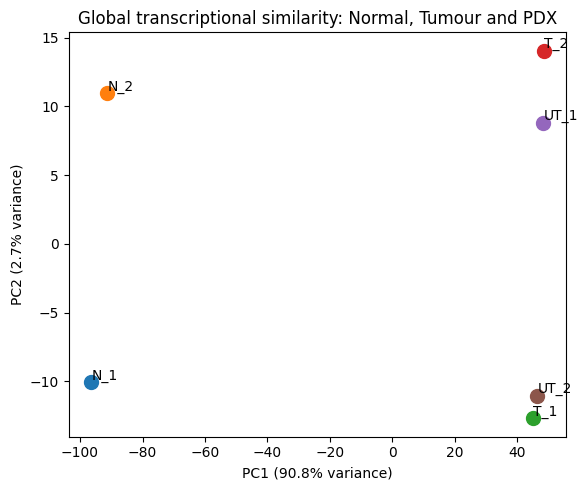

In [8]:
plt.figure(figsize=(6,5))

for sample in pca_df.index:
    plt.scatter(
        pca_df.loc[sample, "PC1"],
        pca_df.loc[sample, "PC2"],
        s=100
    )

    plt.text(
        pca_df.loc[sample, "PC1"] + 0.2,
        pca_df.loc[sample, "PC2"] + 0.2,
        sample
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)"
)

plt.title("Global transcriptional similarity: Normal, Tumour and PDX")
plt.tight_layout()
plt.show()

## 2. Global transcriptional fidelity of the PDX models

PCA suggested that the PDX samples retain the dominant tumour-associated transcriptional state. To quantify this, transcriptome-wide sample correlations and distances to tumour versus normal expression centroids were calculated.

In [9]:
corr = log_cpm.corr(method="spearman")

display(corr.round(3))

,N_1,N_2,T_1,T_2,UT_1,UT_2
N_1,1.000,0.986,0.888,0.883,0.883,0.885
N_2,0.986,1.000,0.895,0.891,0.891,0.893
T_1,0.888,0.895,1.000,0.983,0.983,0.983
T_2,0.883,0.891,0.983,1.000,0.984,0.983
UT_1,0.883,0.891,0.983,0.984,1.000,0.983
UT_2,0.885,0.893,0.983,0.983,0.983,1.000


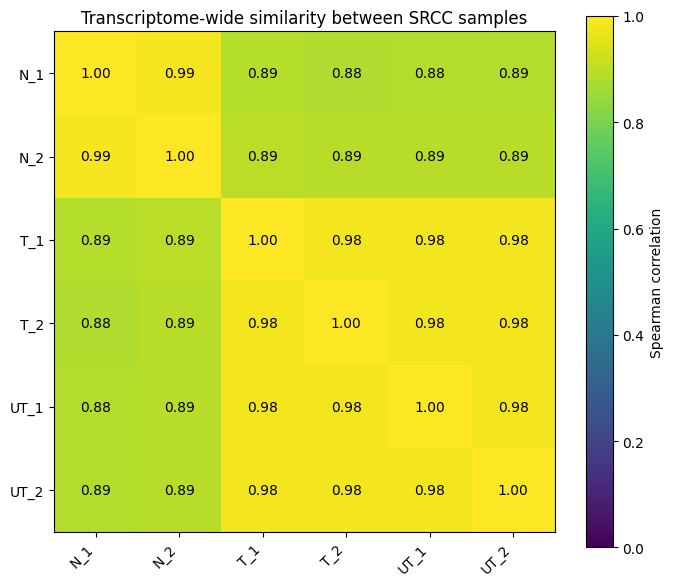

In [10]:
fig, ax = plt.subplots(figsize=(7,6))

im = ax.imshow(
    corr.values,
    vmin=0,
    vmax=1
)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")

ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i,j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(im, ax=ax, label="Spearman correlation")
plt.title("Transcriptome-wide similarity between SRCC samples")
plt.tight_layout()
plt.show()

In [11]:
normal_centroid = log_cpm[["N_1", "N_2"]].mean(axis=1)
tumor_centroid = log_cpm[["T_1", "T_2"]].mean(axis=1)

from scipy.stats import spearmanr

for sample in ["UT_1", "UT_2"]:
    r_tumor, _ = spearmanr(log_cpm[sample], tumor_centroid)
    r_normal, _ = spearmanr(log_cpm[sample], normal_centroid)

    print(sample)
    print("  similarity to tumour:", round(r_tumor, 3))
    print("  similarity to normal:", round(r_normal, 3))
    print()

UT_1
  similarity to tumour: 0.987
  similarity to normal: 0.889

UT_2
  similarity to tumour: 0.987
  similarity to normal: 0.891



## 3. Preservation of tumour-associated transcriptional changes

Global correlation can remain high even between biologically different tissues because most genes are shared.

To test disease-model fidelity more directly, expression changes in primary SRCC relative to adjacent normal tissue were compared with expression changes in PDX relative to adjacent normal tissue.

A faithful model should reproduce both the direction and magnitude of tumour-associated transcriptional changes.

In [12]:
normal_mean = log_cpm[["N_1", "N_2"]].mean(axis=1)
tumor_mean = log_cpm[["T_1", "T_2"]].mean(axis=1)
pdx_mean = log_cpm[["UT_1", "UT_2"]].mean(axis=1)

effects = pd.DataFrame({
    "Tumor_vs_Normal": tumor_mean - normal_mean,
    "PDX_vs_Normal": pdx_mean - normal_mean
})

display(effects.head())

,Tumor_vs_Normal,PDX_vs_Normal
Geneid,,
ENSG00000227232,0.246452,0.177967
ENSG00000268903,1.852672,1.541964
ENSG00000269981,1.365174,1.326422
ENSG00000239906,0.454817,0.528464
ENSG00000241860,0.801053,0.736785


In [13]:
from scipy.stats import spearmanr

r, p = spearmanr(
    effects["Tumor_vs_Normal"],
    effects["PDX_vs_Normal"]
)

print("Tumour-change vs PDX-change correlation:", round(r, 3))
print("p-value:", p)

Tumour-change vs PDX-change correlation: 0.964
p-value: 0.0


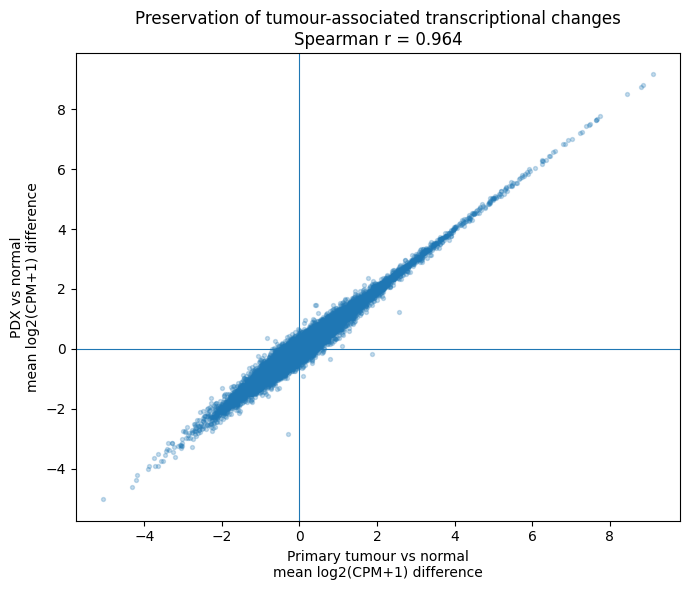

In [14]:
plt.figure(figsize=(7,6))

plt.scatter(
    effects["Tumor_vs_Normal"],
    effects["PDX_vs_Normal"],
    s=8,
    alpha=0.25
)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("Primary tumour vs normal\nmean log2(CPM+1) difference")
plt.ylabel("PDX vs normal\nmean log2(CPM+1) difference")

plt.title(
    f"Preservation of tumour-associated transcriptional changes\n"
    f"Spearman r = {r:.3f}"
)

plt.tight_layout()
plt.show()

In [15]:
strong = effects[
    effects["Tumor_vs_Normal"].abs() > 1
].copy()

same_direction = (
    np.sign(strong["Tumor_vs_Normal"]) ==
    np.sign(strong["PDX_vs_Normal"])
)

print("Genes with |tumour-normal effect| > 1:", len(strong))

print(
    "Same direction in PDX:",
    round(same_direction.mean() * 100, 1),
    "%"
)

Genes with |tumour-normal effect| > 1: 4120
Same direction in PDX: 100.0 %


In [16]:
strong = effects[
    effects["Tumor_vs_Normal"].abs() > 1
].copy()

same_direction = (
    np.sign(strong["Tumor_vs_Normal"]) ==
    np.sign(strong["PDX_vs_Normal"])
)

print("Strongly altered genes:", len(strong))
print(
    "Same direction in PDX:",
    round(same_direction.mean() * 100, 1),
    "%"
)

Strongly altered genes: 4120
Same direction in PDX: 100.0 %


In [17]:
!pip install -q mygene

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.1/52.1 kB 1.8 MB/s eta 0:00:00


In [18]:
import mygene

mg = mygene.MyGeneInfo()

ensembl_ids = effects.index.tolist()

mapping = mg.querymany(
    ensembl_ids,
    scopes="ensembl.gene",
    fields="symbol",
    species="human",
    as_dataframe=True
)

mapping = mapping[["symbol"]].dropna()
mapping = mapping[~mapping.index.duplicated(keep="first")]

print("Mapped genes:", len(mapping))
display(mapping.head())

INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:biothings.client:querying 6001-7000 ...
INFO:biothings.client:querying 7001-8000 ...
INFO:biothings.client:querying 8001-9000 ...
INFO:biothings.client:querying 9001-10000 ...
INFO:biothings.client:querying 10001-11000 ...
INFO:biothings.client:querying 11001-12000 ...
INFO:biothings.client:querying 12001-13000 ...
INFO:biothings.client:querying 13001-14000 ...
INFO:biothings.client:querying 14001-15000 ...
INFO:biothings.client:querying 15001-16000 ...
INFO:biothings.client:querying 16001-17000 ...
INFO:biothings.client:querying 17001-18000 ...
INFO:biothings.client:querying 18001-19000 ...
INFO:biothings.client:querying 19001-20000 ...
INFO:biothings.client:querying 20001-21000 ...
INFO:biothings.client:querying 2100

Mapped genes: 20434


,symbol
query,
ENSG00000227232,WASH7P
ENSG00000279457,WASH9P
ENSG00000228463,RPL23AP21
ENSG00000225972,MTND1P23
ENSG00000225630,MTND2P28


In [19]:
effects_symbols = effects.join(mapping, how="inner")

effects_symbols = (
    effects_symbols
    .dropna(subset=["symbol"])
    .drop_duplicates(subset=["symbol"])
    .set_index("symbol")
)

print(effects_symbols.shape)
display(effects_symbols.head())

(20363, 2)


,Tumor_vs_Normal,PDX_vs_Normal
symbol,,
WASH7P,0.246452,0.177967
WASH9P,0.424952,0.069593
RPL23AP21,0.108814,0.169716
MTND1P23,0.789921,-0.349190
MTND2P28,-1.244079,-1.317805


In [21]:
tumor_rank = (
    effects_symbols["Tumor_vs_Normal"]
    .sort_values(ascending=False)
)

pdx_rank = (
    effects_symbols["PDX_vs_Normal"]
    .sort_values(ascending=False)
)

In [22]:
import gseapy as gp

tumor_gsea = gp.prerank(
    rnk=tumor_rank,
    gene_sets="MSigDB_Hallmark_2020",
    organism="Human",
    permutation_num=1000,
    seed=42,
    verbose=False
)

pdx_gsea = gp.prerank(
    rnk=pdx_rank,
    gene_sets="MSigDB_Hallmark_2020",
    organism="Human",
    permutation_num=1000,
    seed=42,
    verbose=False
)

tumor_pathways = tumor_gsea.res2d.copy()
pdx_pathways = pdx_gsea.res2d.copy()

display(
    tumor_pathways[
        ["Term", "NES", "FDR q-val"]
    ].sort_values("FDR q-val").head(15)
)

display(
    pdx_pathways[
        ["Term", "NES", "FDR q-val"]
    ].sort_values("FDR q-val").head(15)
)

2026-09-23 19:23:32,632 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-23 19:23:58,335 [WARNING] Duplicated values found in preranked stats: 0.23% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Term,NES,FDR q-val
0,TNF-alpha Signaling via NF-kB,2.932341,0.000000
1,Epithelial Mesenchymal Transition,2.816904,0.000000
2,Inflammatory Response,2.778578,0.000000
3,mTORC1 Signaling,2.389758,0.000000
4,E2F Targets,2.320194,0.000000
5,Hypoxia,2.256588,0.000000
6,Angiogenesis,2.254824,0.000000
7,G2-M Checkpoint,2.204579,0.000000
8,Coagulation,2.187619,0.000000
9,Complement,2.161709,0.000000


,Term,NES,FDR q-val
0,TNF-alpha Signaling via NF-kB,2.933923,0.000000
1,Epithelial Mesenchymal Transition,2.834157,0.000000
2,Inflammatory Response,2.702707,0.000000
3,mTORC1 Signaling,2.360247,0.000000
4,E2F Targets,2.332376,0.000000
5,Angiogenesis,2.282068,0.000000
6,G2-M Checkpoint,2.257689,0.000000
7,Hypoxia,2.254507,0.000000
8,Coagulation,2.213533,0.000000
9,Complement,2.166967,0.000000


In [23]:
strong = effects[
    effects["Tumor_vs_Normal"].abs() > 1
].copy()

same_direction = (
    np.sign(strong["Tumor_vs_Normal"]) ==
    np.sign(strong["PDX_vs_Normal"])
)

print("Strongly altered genes:", len(strong))
print(
    "Same direction in PDX:",
    round(same_direction.mean() * 100, 1),
    "%"
)

Strongly altered genes: 4120
Same direction in PDX: 100.0 %


In [24]:
!pip install -q mygene

In [25]:
import mygene

mg = mygene.MyGeneInfo()

mapping = mg.querymany(
    effects.index.tolist(),
    scopes="ensembl.gene",
    fields="symbol",
    species="human",
    as_dataframe=True
)

mapping = mapping[["symbol"]].dropna()
mapping = mapping[~mapping.index.duplicated(keep="first")]

effects_symbols = effects.join(mapping, how="inner")

effects_symbols = (
    effects_symbols
    .dropna(subset=["symbol"])
    .sort_values(
        "Tumor_vs_Normal",
        key=lambda x: x.abs(),
        ascending=False
    )
    .drop_duplicates(subset=["symbol"])
    .set_index("symbol")
)

print("Mapped genes:", len(effects_symbols))

INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:biothings.client:querying 6001-7000 ...
INFO:biothings.client:querying 7001-8000 ...
INFO:biothings.client:querying 8001-9000 ...
INFO:biothings.client:querying 9001-10000 ...
INFO:biothings.client:querying 10001-11000 ...
INFO:biothings.client:querying 11001-12000 ...
INFO:biothings.client:querying 12001-13000 ...
INFO:biothings.client:querying 13001-14000 ...
INFO:biothings.client:querying 14001-15000 ...
INFO:biothings.client:querying 15001-16000 ...
INFO:biothings.client:querying 16001-17000 ...
INFO:biothings.client:querying 17001-18000 ...
INFO:biothings.client:querying 18001-19000 ...
INFO:biothings.client:querying 19001-20000 ...
INFO:biothings.client:querying 20001-21000 ...
INFO:biothings.client:querying 2100

Mapped genes: 20363


In [26]:
import gseapy as gp

tumor_rank = (
    effects_symbols["Tumor_vs_Normal"]
    .sort_values(ascending=False)
)

pdx_rank = (
    effects_symbols["PDX_vs_Normal"]
    .sort_values(ascending=False)
)

tumor_gsea = gp.prerank(
    rnk=tumor_rank,
    gene_sets="MSigDB_Hallmark_2020",
    organism="Human",
    permutation_num=1000,
    seed=42,
    verbose=False
)

pdx_gsea = gp.prerank(
    rnk=pdx_rank,
    gene_sets="MSigDB_Hallmark_2020",
    organism="Human",
    permutation_num=1000,
    seed=42,
    verbose=False
)

tumor_pathways = tumor_gsea.res2d.copy()
pdx_pathways = pdx_gsea.res2d.copy()

2026-09-23 19:28:06,737 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-23 19:28:17,037 [WARNING] Duplicated values found in preranked stats: 0.22% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


In [27]:
display(
    tumor_pathways[
        ["Term", "NES", "FDR q-val"]
    ].sort_values("FDR q-val").head(15)
)

display(
    pdx_pathways[
        ["Term", "NES", "FDR q-val"]
    ].sort_values("FDR q-val").head(15)
)

,Term,NES,FDR q-val
0,TNF-alpha Signaling via NF-kB,2.930069,0.0
1,Epithelial Mesenchymal Transition,2.826752,0.0
2,Inflammatory Response,2.751694,0.0
3,mTORC1 Signaling,2.399161,0.0
4,E2F Targets,2.337803,0.0
5,Angiogenesis,2.270142,0.0
6,Hypoxia,2.261150,0.0
7,G2-M Checkpoint,2.214704,0.0
8,Coagulation,2.207736,0.0
9,Complement,2.159486,0.0


,Term,NES,FDR q-val
0,TNF-alpha Signaling via NF-kB,2.945150,0.0
1,Epithelial Mesenchymal Transition,2.874331,0.0
2,Inflammatory Response,2.707870,0.0
3,mTORC1 Signaling,2.384182,0.0
4,E2F Targets,2.357206,0.0
5,Angiogenesis,2.304596,0.0
6,G2-M Checkpoint,2.254022,0.0
7,Hypoxia,2.244601,0.0
8,Coagulation,2.203712,0.0
9,Complement,2.188937,0.0


In [28]:
pathway_compare = (
    tumor_pathways[
        ["Term", "NES", "FDR q-val"]
    ]
    .merge(
        pdx_pathways[
            ["Term", "NES", "FDR q-val"]
        ],
        on="Term",
        suffixes=("_tumor", "_pdx")
    )
)

display(pathway_compare.head())

,Term,NES_tumor,FDR q-val_tumor,NES_pdx,FDR q-val_pdx
0,TNF-alpha Signaling via NF-kB,2.930069,0.0,2.945150,0.0
1,Epithelial Mesenchymal Transition,2.826752,0.0,2.874331,0.0
2,Inflammatory Response,2.751694,0.0,2.707870,0.0
3,mTORC1 Signaling,2.399161,0.0,2.384182,0.0
4,E2F Targets,2.337803,0.0,2.357206,0.0


In [29]:
from scipy.stats import spearmanr

pathway_r, pathway_p = spearmanr(
    pathway_compare["NES_tumor"],
    pathway_compare["NES_pdx"]
)

print("Pathway NES concordance:", round(pathway_r, 3))
print("p-value:", pathway_p)

Pathway NES concordance: 0.998
p-value: 6.454141645455264e-57


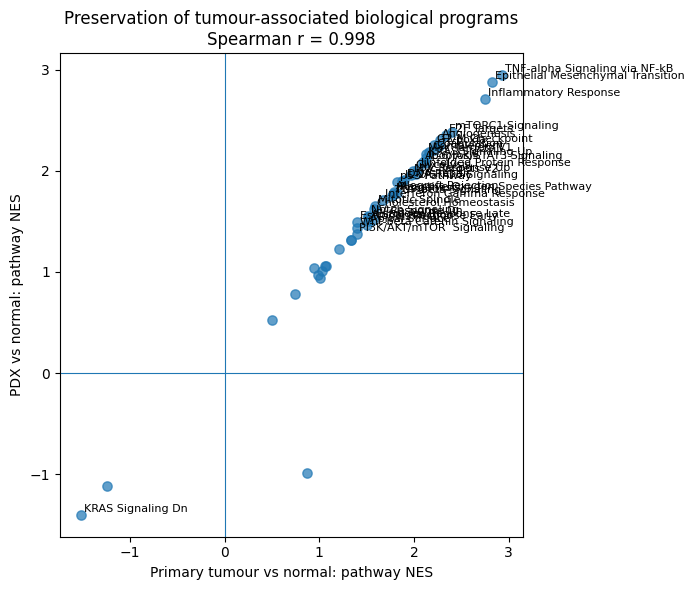

In [30]:
plt.figure(figsize=(7,6))

plt.scatter(
    pathway_compare["NES_tumor"],
    pathway_compare["NES_pdx"],
    s=45,
    alpha=0.7
)

for _, row in pathway_compare.iterrows():
    if (
        row["FDR q-val_tumor"] < 0.05
        or row["FDR q-val_pdx"] < 0.05
    ):
        plt.text(
            row["NES_tumor"] + 0.03,
            row["NES_pdx"] + 0.03,
            row["Term"],
            fontsize=8
        )

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("Primary tumour vs normal: pathway NES")
plt.ylabel("PDX vs normal: pathway NES")

plt.title(
    f"Preservation of tumour-associated biological programs\n"
    f"Spearman r = {pathway_r:.3f}"
)

plt.tight_layout()
plt.show()

In [31]:
preserved = pathway_compare[
    (pathway_compare["FDR q-val_tumor"] < 0.05) &
    (pathway_compare["FDR q-val_pdx"] < 0.05) &
    (
        np.sign(pathway_compare["NES_tumor"]) ==
        np.sign(pathway_compare["NES_pdx"])
    )
].copy()

lost = pathway_compare[
    (pathway_compare["FDR q-val_tumor"] < 0.05) &
    (pathway_compare["FDR q-val_pdx"] >= 0.05)
].copy()

pdx_acquired = pathway_compare[
    (pathway_compare["FDR q-val_tumor"] >= 0.05) &
    (pathway_compare["FDR q-val_pdx"] < 0.05)
].copy()

print("Preserved:", len(preserved))
print("Lost:", len(lost))
print("PDX-acquired:", len(pdx_acquired))

print("\nPRESERVED")
display(
    preserved[
        ["Term", "NES_tumor", "NES_pdx"]
    ].sort_values("NES_tumor", ascending=False)
)

print("\nLOST")
display(
    lost[
        ["Term", "NES_tumor", "NES_pdx"]
    ]
)

print("\nPDX-ACQUIRED")
display(
    pdx_acquired[
        ["Term", "NES_tumor", "NES_pdx"]
    ]
)

Preserved: 35
Lost: 2
PDX-acquired: 0

PRESERVED


,Term,NES_tumor,NES_pdx
0,TNF-alpha Signaling via NF-kB,2.930069,2.945150
1,Epithelial Mesenchymal Transition,2.826752,2.874331
2,Inflammatory Response,2.751694,2.707870
3,mTORC1 Signaling,2.399161,2.384182
4,E2F Targets,2.337803,2.357206
5,Angiogenesis,2.270142,2.304596
6,Hypoxia,2.261150,2.244601
7,G2-M Checkpoint,2.214704,2.254022
8,Coagulation,2.207736,2.203712
9,Complement,2.159486,2.188937



LOST


,Term,NES_tumor,NES_pdx
29,KRAS Signaling Dn,-1.519564,-1.399499
36,PI3K/AKT/mTOR Signaling,1.393814,1.370628



PDX-ACQUIRED


,Term,NES_tumor,NES_pdx


In [32]:
print("Pathway NES correlation:", round(pathway_r, 3))
print("Preserved:", len(preserved))
print("Not significant in PDX:", len(lost))
print("PDX-acquired:", len(pdx_acquired))

Pathway NES correlation: 0.998
Preserved: 35
Not significant in PDX: 2
PDX-acquired: 0


In [33]:
libraries = gp.get_library_name(organism="Human")

print("Reactome libraries:")
print([x for x in libraries if "Reactome" in x])

print("\nGO Biological Process libraries:")
print([x for x in libraries if "GO_Biological_Process" in x])

Reactome libraries:
['Reactome_2022', 'Reactome_Pathways_2024']

GO Biological Process libraries:
['GO_Biological_Process_2021', 'GO_Biological_Process_2023', 'GO_Biological_Process_2025', 'GO_Biological_Process_2026']


In [34]:
tumor_reactome = gp.prerank(
    rnk=tumor_rank,
    gene_sets="Reactome_Pathways_2024",
    organism="Human",
    permutation_num=1000,
    seed=42,
    verbose=False
)

pdx_reactome = gp.prerank(
    rnk=pdx_rank,
    gene_sets="Reactome_Pathways_2024",
    organism="Human",
    permutation_num=1000,
    seed=42,
    verbose=False
)

tumor_reactome_df = tumor_reactome.res2d.copy()
pdx_reactome_df = pdx_reactome.res2d.copy()

2026-09-23 19:34:22,158 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-23 19:37:30,256 [WARNING] Duplicated values found in preranked stats: 0.22% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


In [35]:
autophagy_terms_tumor = tumor_reactome_df[
    tumor_reactome_df["Term"]
    .str.contains("autoph|lysosom", case=False, regex=True)
][["Term", "NES", "FDR q-val"]]

autophagy_terms_pdx = pdx_reactome_df[
    pdx_reactome_df["Term"]
    .str.contains("autoph|lysosom", case=False, regex=True)
][["Term", "NES", "FDR q-val"]]

print("TUMOUR")
display(
    autophagy_terms_tumor.sort_values(
        "FDR q-val"
    )
)

print("\nPDX")
display(
    autophagy_terms_pdx.sort_values(
        "FDR q-val"
    )
)

TUMOUR


,Term,NES,FDR q-val
574,Regulation of MITF-M-dependent Genes Involved ...,1.481851,0.071234
757,Autophagy,1.313526,0.172184
808,Chaperone Mediated Autophagy,1.263516,0.216858
861,Macroautophagy,1.200966,0.284309
917,Late Endosomal Microautophagy,1.139170,0.358796
918,Selective Autophagy,1.138622,0.359239
1011,Lysosome Vesicle Biogenesis,1.044505,0.480660



PDX


,Term,NES,FDR q-val
548,Regulation of MITF-M-dependent Genes Involved ...,1.528409,0.052653
746,Chaperone Mediated Autophagy,1.327483,0.163549
751,Autophagy,1.320634,0.169119
848,Macroautophagy,1.202218,0.287605
954,Selective Autophagy,1.114783,0.385888
970,Late Endosomal Microautophagy,1.097767,0.407516
1036,Lysosome Vesicle Biogenesis,1.033648,0.490348


In [36]:
autophagy_compare = (
    autophagy_terms_tumor
    .merge(
        autophagy_terms_pdx,
        on="Term",
        suffixes=("_tumor", "_pdx")
    )
)

display(autophagy_compare)

,Term,NES_tumor,FDR q-val_tumor,NES_pdx,FDR q-val_pdx
0,Regulation of MITF-M-dependent Genes Involved ...,1.481851,0.071234,1.528409,0.052653
1,Autophagy,1.313526,0.172184,1.320634,0.169119
2,Chaperone Mediated Autophagy,1.263516,0.216858,1.327483,0.163549
3,Macroautophagy,1.200966,0.284309,1.202218,0.287605
4,Late Endosomal Microautophagy,1.139170,0.358796,1.097767,0.407516
5,Selective Autophagy,1.138622,0.359239,1.114783,0.385888
6,Lysosome Vesicle Biogenesis,1.044505,0.480660,1.033648,0.490348


In [ ]:
tumor_go = gp.prerank(
    rnk=tumor_rank,
    gene_sets="GO_Biological_Process_2025",
    organism="Human",
    permutation_num=1000,
    seed=42,
    verbose=False
)

pdx_go = gp.prerank(
    rnk=pdx_rank,
    gene_sets="GO_Biological_Process_2025",
    organism="Human",
    permutation_num=1000,
    seed=42,
    verbose=False
)

tumor_go_df = tumor_go.res2d.copy()
pdx_go_df = pdx_go.res2d.copy()

2026-09-23 19:42:25,736 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-23 19:47:48,233 [WARNING] Duplicated values found in preranked stats: 0.22% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


In [1]:
tumor_go_autophagy = tumor_go_df[
    tumor_go_df["Term"]
    .str.contains(
        "autoph|lysosom|phagophore",
        case=False,
        regex=True
    )
][["Term", "NES", "FDR q-val"]]

pdx_go_autophagy = pdx_go_df[
    pdx_go_df["Term"]
    .str.contains(
        "autoph|lysosom|phagophore",
        case=False,
        regex=True
    )
][["Term", "NES", "FDR q-val"]]

print("TUMOUR GO")
display(
    tumor_go_autophagy
    .sort_values("FDR q-val")
    .head(20)
)

print("\nPDX GO")
display(
    pdx_go_autophagy
    .sort_values("FDR q-val")
    .head(20)
)

NameError: name 'tumor_go_df' is not defined

In [2]:
tumor_go = gp.prerank(
    rnk=tumor_rank,
    gene_sets="GO_Biological_Process_2025",
    organism="Human",
    permutation_num=1000,
    seed=42,
    verbose=False
)

pdx_go = gp.prerank(
    rnk=pdx_rank,
    gene_sets="GO_Biological_Process_2025",
    organism="Human",
    permutation_num=1000,
    seed=42,
    verbose=False
)

tumor_go_df = tumor_go.res2d.copy()
pdx_go_df = pdx_go.res2d.copy()

print("Tumour GO pathways:", tumor_go_df.shape)
print("PDX GO pathways:", pdx_go_df.shape)

NameError: name 'gp' is not defined

In [3]:
!pip install -q pandas==2.2.3 gseapy mygene

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.7/689.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.1/52.1 kB 4.6 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gseapy as gp
import mygene

print("Libraries working")

Libraries working


In [5]:
print("tumor_rank exists:", "tumor_rank" in globals())
print("pdx_rank exists:", "pdx_rank" in globals())

tumor_rank exists: False
pdx_rank exists: False


In [6]:
import os
import pandas as pd
import numpy as np

if not os.path.exists("SRCC_raw_counts.txt.gz"):
    !wget -q \
    "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE279nnn/GSE279979/suppl/GSE279979_raw_counts.txt.gz" \
    -O SRCC_raw_counts.txt.gz

print("Raw file ready")

Raw file ready


In [7]:
counts_raw = pd.read_csv(
    "SRCC_raw_counts.txt.gz",
    sep="\t"
)

sample_cols = ["N_1", "N_2", "T_1", "T_2", "UT_1", "UT_2"]

counts = counts_raw[
    ["Geneid"] + sample_cols
].copy()

counts["Geneid"] = counts["Geneid"].str.split(".").str[0]

counts = counts.set_index("Geneid")

# remove very low-information genes
keep = (counts >= 10).sum(axis=1) >= 2
counts_filt = counts.loc[keep]

# normalize for descriptive/pathway analysis
libsize = counts_filt.sum(axis=0)
norm = counts_filt.div(libsize, axis=1) * 1e6
log_cpm = np.log2(norm + 1)

print("Genes retained:", log_cpm.shape[0])

Genes retained: 23796


In [8]:
normal_mean = log_cpm[["N_1", "N_2"]].mean(axis=1)
tumor_mean = log_cpm[["T_1", "T_2"]].mean(axis=1)
pdx_mean = log_cpm[["UT_1", "UT_2"]].mean(axis=1)

effects = pd.DataFrame({
    "Tumor_vs_Normal": tumor_mean - normal_mean,
    "PDX_vs_Normal": pdx_mean - normal_mean
})

print(effects.shape)

(23796, 2)


In [9]:
import mygene

mg = mygene.MyGeneInfo()

mapping = mg.querymany(
    effects.index.tolist(),
    scopes="ensembl.gene",
    fields="symbol",
    species="human",
    as_dataframe=True
)

mapping = mapping[["symbol"]].dropna()
mapping = mapping[~mapping.index.duplicated(keep="first")]

effects_symbols = effects.join(mapping, how="inner")

effects_symbols = (
    effects_symbols
    .dropna(subset=["symbol"])
    .sort_values(
        "Tumor_vs_Normal",
        key=lambda x: x.abs(),
        ascending=False
    )
    .drop_duplicates(subset=["symbol"])
    .set_index("symbol")
)

print("Mapped genes:", len(effects_symbols))

INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:biothings.client:querying 6001-7000 ...
INFO:biothings.client:querying 7001-8000 ...
INFO:biothings.client:querying 8001-9000 ...
INFO:biothings.client:querying 9001-10000 ...
INFO:biothings.client:querying 10001-11000 ...
INFO:biothings.client:querying 11001-12000 ...
INFO:biothings.client:querying 12001-13000 ...
INFO:biothings.client:querying 13001-14000 ...
INFO:biothings.client:querying 14001-15000 ...
INFO:biothings.client:querying 15001-16000 ...
INFO:biothings.client:querying 16001-17000 ...
INFO:biothings.client:querying 17001-18000 ...
INFO:biothings.client:querying 18001-19000 ...
INFO:biothings.client:querying 19001-20000 ...
INFO:biothings.client:querying 20001-21000 ...
INFO:biothings.client:querying 2100

Mapped genes: 20363


In [10]:
tumor_rank = (
    effects_symbols["Tumor_vs_Normal"]
    .sort_values(ascending=False)
)

pdx_rank = (
    effects_symbols["PDX_vs_Normal"]
    .sort_values(ascending=False)
)

print("tumor_rank:", len(tumor_rank))
print("pdx_rank:", len(pdx_rank))

tumor_rank: 20363
pdx_rank: 20363


In [11]:
import gseapy as gp

tumor_reactome = gp.prerank(
    rnk=tumor_rank,
    gene_sets="Reactome_Pathways_2024",
    organism="Human",
    permutation_num=1000,
    seed=42,
    verbose=False
)

pdx_reactome = gp.prerank(
    rnk=pdx_rank,
    gene_sets="Reactome_Pathways_2024",
    organism="Human",
    permutation_num=1000,
    seed=42,
    verbose=False
)

tumor_reactome_df = tumor_reactome.res2d.copy()
pdx_reactome_df = pdx_reactome.res2d.copy()

print("Reactome done")

2026-09-24 07:25:48,922 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-24 07:27:46,071 [WARNING] Duplicated values found in preranked stats: 0.22% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Reactome done


In [12]:
tumor_autophagy = tumor_reactome_df[
    tumor_reactome_df["Term"].str.contains(
        "autoph|lysosom",
        case=False,
        regex=True
    )
][["Term", "NES", "FDR q-val"]]

pdx_autophagy = pdx_reactome_df[
    pdx_reactome_df["Term"].str.contains(
        "autoph|lysosom",
        case=False,
        regex=True
    )
][["Term", "NES", "FDR q-val"]]

print("PRIMARY TUMOUR")
display(tumor_autophagy.sort_values("FDR q-val"))

print("\nPDX")
display(pdx_autophagy.sort_values("FDR q-val"))

PRIMARY TUMOUR


,Term,NES,FDR q-val
574,Regulation of MITF-M-dependent Genes Involved ...,1.481851,0.071234
757,Autophagy,1.313526,0.172184
808,Chaperone Mediated Autophagy,1.263516,0.216858
861,Macroautophagy,1.200966,0.284309
917,Late Endosomal Microautophagy,1.139170,0.358796
918,Selective Autophagy,1.138622,0.359239
1011,Lysosome Vesicle Biogenesis,1.044505,0.480660



PDX


,Term,NES,FDR q-val
548,Regulation of MITF-M-dependent Genes Involved ...,1.528409,0.052653
746,Chaperone Mediated Autophagy,1.327483,0.163549
751,Autophagy,1.320634,0.169119
848,Macroautophagy,1.202218,0.287605
954,Selective Autophagy,1.114783,0.385888
970,Late Endosomal Microautophagy,1.097767,0.407516
1036,Lysosome Vesicle Biogenesis,1.033648,0.490348


In [13]:
autophagy_compare = tumor_autophagy.merge(
    pdx_autophagy,
    on="Term",
    suffixes=("_tumor", "_pdx")
)

display(
    autophagy_compare.sort_values("FDR q-val_tumor")
)

,Term,NES_tumor,FDR q-val_tumor,NES_pdx,FDR q-val_pdx
0,Regulation of MITF-M-dependent Genes Involved ...,1.481851,0.071234,1.528409,0.052653
1,Autophagy,1.313526,0.172184,1.320634,0.169119
2,Chaperone Mediated Autophagy,1.263516,0.216858,1.327483,0.163549
3,Macroautophagy,1.200966,0.284309,1.202218,0.287605
4,Late Endosomal Microautophagy,1.139170,0.358796,1.097767,0.407516
5,Selective Autophagy,1.138622,0.359239,1.114783,0.385888
6,Lysosome Vesicle Biogenesis,1.044505,0.480660,1.033648,0.490348


In [14]:
tumor_go = gp.prerank(
    rnk=tumor_rank,
    gene_sets="GO_Biological_Process_2025",
    organism="Human",
    permutation_num=1000,
    seed=42,
    verbose=False
)

pdx_go = gp.prerank(
    rnk=pdx_rank,
    gene_sets="GO_Biological_Process_2025",
    organism="Human",
    permutation_num=1000,
    seed=42,
    verbose=False
)

tumor_go_df = tumor_go.res2d.copy()
pdx_go_df = pdx_go.res2d.copy()

2026-09-24 07:30:39,006 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-24 07:34:03,250 [WARNING] Duplicated values found in preranked stats: 0.22% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


In [15]:
tumor_go_autophagy = tumor_go_df[
    tumor_go_df["Term"].str.contains(
        "autoph|lysosom|phagophore",
        case=False,
        regex=True
    )
][["Term", "NES", "FDR q-val"]]

pdx_go_autophagy = pdx_go_df[
    pdx_go_df["Term"].str.contains(
        "autoph|lysosom|phagophore",
        case=False,
        regex=True
    )
][["Term", "NES", "FDR q-val"]]

print("TUMOUR GO")
display(tumor_go_autophagy.sort_values("FDR q-val").head(20))

print("\nPDX GO")
display(pdx_go_autophagy.sort_values("FDR q-val").head(20))

TUMOUR GO


,Term,NES,FDR q-val
681,Regulation of Autophagy (GO:0010506),1.483177,0.127529
794,Protein Autophosphorylation (GO:0046777),1.431545,0.158807
868,Regulation of Lysosomal Lumen pH (GO:0035751),1.399981,0.179270
899,Regulation of Macroautophagy (GO:0016241),1.387487,0.188166
917,Negative Regulation of Autophagy (GO:0010507),1.382288,0.191424
953,Lysosomal Lumen Acidification (GO:0007042),1.368552,0.201236
1092,Positive Regulation of Autophagy (GO:0010508),1.310290,0.248696
1151,Protein Localization to Lysosome (GO:0061462),1.286254,0.270071
1443,Autophagosome Assembly (GO:0000045),1.156909,0.411133
1500,Autophagosome Organization (GO:1905037),1.133279,0.438181



PDX GO


,Term,NES,FDR q-val
633,Regulation of Autophagy (GO:0010506),1.510912,0.112366
862,Regulation of Lysosomal Lumen pH (GO:0035751),1.406874,0.172695
867,Negative Regulation of Autophagy (GO:0010507),1.405624,0.173048
875,Protein Autophosphorylation (GO:0046777),1.403168,0.174267
973,Lysosomal Lumen Acidification (GO:0007042),1.359402,0.206745
996,Regulation of Macroautophagy (GO:0016241),1.349730,0.214265
1164,Positive Regulation of Autophagy (GO:0010508),1.276569,0.279647
1234,Autophagosome Assembly (GO:0000045),1.250075,0.302274
1334,Protein Localization to Lysosome (GO:0061462),1.210201,0.343039
1394,Autophagosome Organization (GO:1905037),1.181287,0.377821


In [16]:
print("Gene-effect correlation:", round(r, 3))
print("Strong genes:", len(strong))
print("Same direction:", round(same_direction.mean()*100, 1), "%")

print("Pathway NES correlation:", round(pathway_r, 3))

print("Preserved significant pathways:", len(preserved))
print("Tumour-significant, PDX non-significant:", len(lost))
print("PDX-acquired significant pathways:", len(pdx_acquired))

NameError: name 'r' is not defined

In [17]:
from scipy.stats import spearmanr
import numpy as np

# 1. Gene-level fidelity
r, gene_p = spearmanr(
    effects["Tumor_vs_Normal"],
    effects["PDX_vs_Normal"]
)

strong = effects[
    effects["Tumor_vs_Normal"].abs() > 1
].copy()

same_direction = (
    np.sign(strong["Tumor_vs_Normal"]) ==
    np.sign(strong["PDX_vs_Normal"])
)

# 2. Rebuild pathway comparison
pathway_compare = (
    tumor_pathways[
        ["Term", "NES", "FDR q-val"]
    ]
    .merge(
        pdx_pathways[
            ["Term", "NES", "FDR q-val"]
        ],
        on="Term",
        suffixes=("_tumor", "_pdx")
    )
)

# 3. Pathway-level fidelity
pathway_r, pathway_p = spearmanr(
    pathway_compare["NES_tumor"],
    pathway_compare["NES_pdx"]
)

# 4. Classify pathways
preserved = pathway_compare[
    (pathway_compare["FDR q-val_tumor"] < 0.05) &
    (pathway_compare["FDR q-val_pdx"] < 0.05) &
    (
        np.sign(pathway_compare["NES_tumor"]) ==
        np.sign(pathway_compare["NES_pdx"])
    )
].copy()

lost = pathway_compare[
    (pathway_compare["FDR q-val_tumor"] < 0.05) &
    (pathway_compare["FDR q-val_pdx"] >= 0.05)
].copy()

pdx_acquired = pathway_compare[
    (pathway_compare["FDR q-val_tumor"] >= 0.05) &
    (pathway_compare["FDR q-val_pdx"] < 0.05)
].copy()

# 5. Final summary
print("Gene-effect correlation:", round(r, 3))
print("Strongly altered genes:", len(strong))
print("Same direction in PDX:", round(same_direction.mean()*100, 1), "%")
print()
print("Pathway NES correlation:", round(pathway_r, 3))
print("Preserved significant pathways:", len(preserved))
print("Tumour-significant / PDX non-significant:", len(lost))
print("PDX-acquired significant pathways:", len(pdx_acquired))

NameError: name 'tumor_pathways' is not defined

In [18]:
import gseapy as gp

# Recreate ranked lists if needed
if "tumor_rank" not in globals() or "pdx_rank" not in globals():
    tumor_rank = (
        effects_symbols["Tumor_vs_Normal"]
        .sort_values(ascending=False)
    )

    pdx_rank = (
        effects_symbols["PDX_vs_Normal"]
        .sort_values(ascending=False)
    )

# Hallmark GSEA
tumor_gsea = gp.prerank(
    rnk=tumor_rank,
    gene_sets="MSigDB_Hallmark_2020",
    organism="Human",
    permutation_num=1000,
    seed=42,
    verbose=False
)

pdx_gsea = gp.prerank(
    rnk=pdx_rank,
    gene_sets="MSigDB_Hallmark_2020",
    organism="Human",
    permutation_num=1000,
    seed=42,
    verbose=False
)

tumor_pathways = tumor_gsea.res2d.copy()
pdx_pathways = pdx_gsea.res2d.copy()

print("Tumour pathways:", len(tumor_pathways))
print("PDX pathways:", len(pdx_pathways))

2026-09-24 07:44:08,300 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-24 07:44:14,741 [WARNING] Duplicated values found in preranked stats: 0.22% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Tumour pathways: 50
PDX pathways: 50


In [19]:
from scipy.stats import spearmanr
import numpy as np

# Gene-level fidelity
r, gene_p = spearmanr(
    effects["Tumor_vs_Normal"],
    effects["PDX_vs_Normal"]
)

strong = effects[
    effects["Tumor_vs_Normal"].abs() > 1
].copy()

same_direction = (
    np.sign(strong["Tumor_vs_Normal"]) ==
    np.sign(strong["PDX_vs_Normal"])
)

# Pathway comparison
pathway_compare = (
    tumor_pathways[
        ["Term", "NES", "FDR q-val"]
    ]
    .merge(
        pdx_pathways[
            ["Term", "NES", "FDR q-val"]
        ],
        on="Term",
        suffixes=("_tumor", "_pdx")
    )
)

pathway_r, pathway_p = spearmanr(
    pathway_compare["NES_tumor"],
    pathway_compare["NES_pdx"]
)

preserved = pathway_compare[
    (pathway_compare["FDR q-val_tumor"] < 0.05) &
    (pathway_compare["FDR q-val_pdx"] < 0.05) &
    (
        np.sign(pathway_compare["NES_tumor"]) ==
        np.sign(pathway_compare["NES_pdx"])
    )
].copy()

lost = pathway_compare[
    (pathway_compare["FDR q-val_tumor"] < 0.05) &
    (pathway_compare["FDR q-val_pdx"] >= 0.05)
].copy()

pdx_acquired = pathway_compare[
    (pathway_compare["FDR q-val_tumor"] >= 0.05) &
    (pathway_compare["FDR q-val_pdx"] < 0.05)
].copy()

print("Gene-effect correlation:", round(r, 3))
print("Strongly altered genes:", len(strong))
print("Same direction in PDX:", round(same_direction.mean()*100, 1), "%")
print()
print("Pathway NES correlation:", round(pathway_r, 3))
print("Preserved significant pathways:", len(preserved))
print("Tumour-significant / PDX non-significant:", len(lost))
print("PDX-acquired significant pathways:", len(pdx_acquired))

Gene-effect correlation: 0.964
Strongly altered genes: 4120
Same direction in PDX: 100.0 %

Pathway NES correlation: 0.998
Preserved significant pathways: 35
Tumour-significant / PDX non-significant: 2
PDX-acquired significant pathways: 0


In [20]:
# Direct PDX vs primary tumour difference
direct_effect = pdx_mean - tumor_mean

print("Median absolute PDX-vs-tumour difference:",
      round(direct_effect.abs().median(), 3))

print("90th percentile absolute difference:",
      round(direct_effect.abs().quantile(0.90), 3))

print("Genes with |PDX - tumour| > 1:",
      (direct_effect.abs() > 1).sum())

Median absolute PDX-vs-tumour difference: 0.084
90th percentile absolute difference: 0.275
Genes with |PDX - tumour| > 1: 8


In [21]:
direct_rank = (
    effects_symbols["PDX_vs_Normal"]
    - effects_symbols["Tumor_vs_Normal"]
).sort_values(ascending=False)

direct_gsea = gp.prerank(
    rnk=direct_rank,
    gene_sets="MSigDB_Hallmark_2020",
    organism="Human",
    permutation_num=1000,
    seed=42,
    verbose=False
)

direct_pathways = (
    direct_gsea.res2d
    .sort_values("FDR q-val")
    .reset_index(drop=True)
)

display(
    direct_pathways[
        ["Term", "NES", "FDR q-val"]
    ].head(15)
)

print(
    "Significant PDX-vs-tumour pathways:",
    (direct_pathways["FDR q-val"] < 0.05).sum()
)

2026-09-24 07:46:02,447 [WARNING] Duplicated values found in preranked stats: 0.62% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Term,NES,FDR q-val
0,KRAS Signaling Dn,1.349289,0.332823
1,Interferon Alpha Response,1.295418,0.345803
2,Pancreas Beta Cells,1.375521,0.501553
3,Angiogenesis,0.463543,0.999907
4,Apical Junction,-0.994694,1.000000
5,Pperoxisome,-0.924720,1.000000
6,p53 Pathway,0.904457,1.000000
7,IL-6/JAK/STAT3 Signaling,-1.149489,1.000000
8,Notch Signaling,0.849322,1.000000
9,Estrogen Response Late,0.842521,1.000000


Significant PDX-vs-tumour pathways: 0


In [22]:
direct_effect = pdx_mean - tumor_mean

print(
    "Median absolute PDX-vs-tumour difference:",
    round(direct_effect.abs().median(), 3)
)

print(
    "Genes with |PDX - tumour| > 1:",
    (direct_effect.abs() > 1).sum()
)

Median absolute PDX-vs-tumour difference: 0.084
Genes with |PDX - tumour| > 1: 8


In [ ]:
# Transcriptional Fidelity of Patient-Derived Xenograft Models in Colorectal Signet-Ring Cell Carcinoma

Independent exploratory re-analysis of public bulk RNA-seq data from GSE279979.

## Research question

How faithfully do colorectal signet-ring cell carcinoma (SRCC) patient-derived xenograft models preserve the transcriptional state and biological programmes of the primary human tumour?

The public dataset contains only two adjacent-normal, two primary-tumour and two PDX samples. This analysis is therefore descriptive and hypothesis-generating rather than a definitive validation study.

## 1. Dataset and preprocessing

## 2. Global transcriptional similarity

## 3. Preservation of tumour-associated gene-expression changes

## 4. Preservation of tumour-associated biological programmes

## 5. Direct PDX versus primary-tumour comparison

## 6. Autophagy-related programme analysis

## 7. Interpretation and limitations

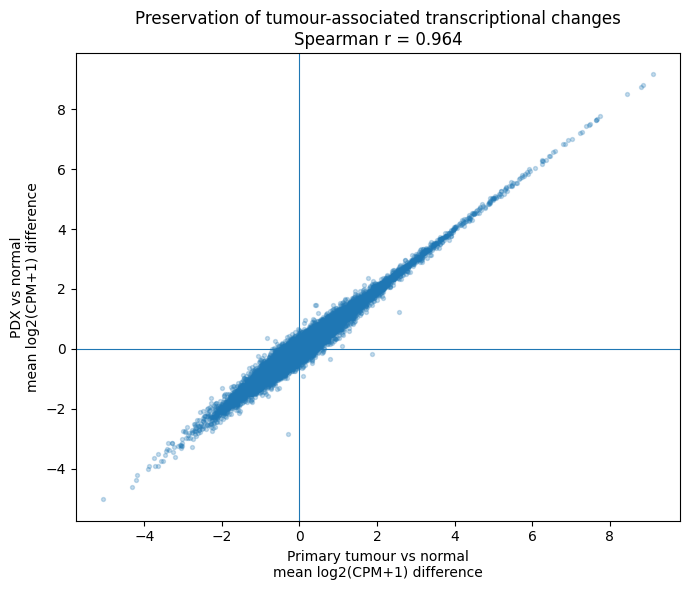

In [23]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

r, p = spearmanr(
    effects["Tumor_vs_Normal"],
    effects["PDX_vs_Normal"]
)

plt.figure(figsize=(7,6))

plt.scatter(
    effects["Tumor_vs_Normal"],
    effects["PDX_vs_Normal"],
    s=8,
    alpha=0.25
)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("Primary tumour vs normal\nmean log2(CPM+1) difference")
plt.ylabel("PDX vs normal\nmean log2(CPM+1) difference")

plt.title(
    "Preservation of tumour-associated transcriptional changes\n"
    f"Spearman r = {r:.3f}"
)

plt.tight_layout()

plt.savefig(
    "SRCC_gene_effect_fidelity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

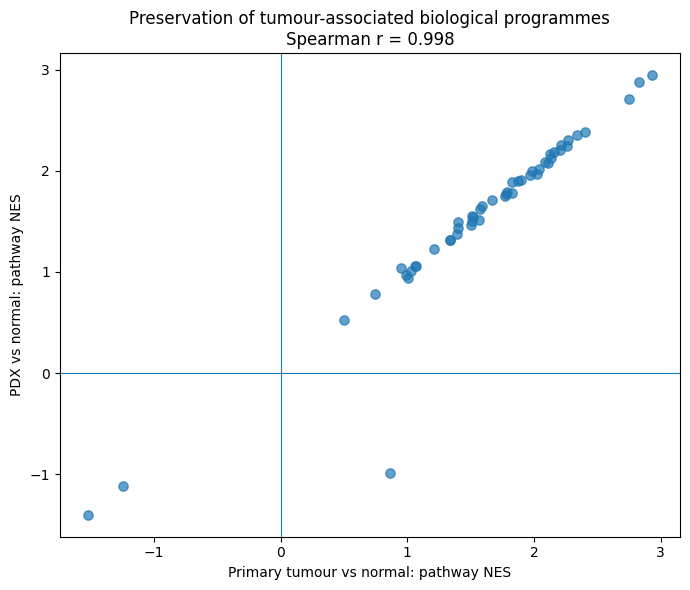

In [24]:
from scipy.stats import spearmanr

pathway_r, pathway_p = spearmanr(
    pathway_compare["NES_tumor"],
    pathway_compare["NES_pdx"]
)

plt.figure(figsize=(7,6))

plt.scatter(
    pathway_compare["NES_tumor"],
    pathway_compare["NES_pdx"],
    s=45,
    alpha=0.7
)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("Primary tumour vs normal: pathway NES")
plt.ylabel("PDX vs normal: pathway NES")

plt.title(
    "Preservation of tumour-associated biological programmes\n"
    f"Spearman r = {pathway_r:.3f}"
)

plt.tight_layout()

plt.savefig(
    "SRCC_pathway_fidelity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
effects.to_csv(
    "SRCC_gene_effects_tumour_PDX_vs_normal.csv"
)

pathway_compare.to_csv(
    "SRCC_Hallmark_pathway_fidelity.csv",
    index=False
)

preserved.to_csv(
    "SRCC_preserved_significant_pathways.csv",
    index=False
)

lost.to_csv(
    "SRCC_tumour_significant_PDX_nonsignificant.csv",
    index=False
)

pdx_acquired.to_csv(
    "SRCC_PDX_acquired_pathways.csv",
    index=False
)

direct_pathways.to_csv(
    "SRCC_direct_PDX_vs_tumour_GSEA.csv",
    index=False
)

autophagy_compare.to_csv(
    "SRCC_autophagy_Reactome_comparison.csv",
    index=False
)

print("Final project outputs saved.")

Final project outputs saved.


In [26]:
## 7. Interpretation and limitations

### Main observation

The PDX models retained a highly tumour-like global transcriptional state.

Both PDX samples showed stronger transcriptome-wide similarity to the primary-tumour centroid (Spearman r ≈ 0.987) than to adjacent normal tissue (≈0.89).

Tumour-associated gene-expression changes were also strongly concordant with changes observed in PDX models (Spearman r = 0.964).

At the pathway level, tumour-associated Hallmark enrichment scores were nearly identical between primary tumours and PDX models (Spearman r = 0.998). Thirty-five significant tumour-associated Hallmark programmes were retained in PDX, while no significant PDX-specific Hallmark programmes were detected.

A direct PDX-versus-primary-tumour comparison identified no Hallmark pathway significantly altered at FDR < 0.05. The median absolute transcriptomic difference between PDX and tumour was 0.084 log2(CPM+1), with only eight genes showing an absolute difference greater than 1.

Together, these descriptive results suggest that the available SRCC PDX models retain much of the dominant primary-tumour transcriptional state and pathway-level biology.

### Autophagy-related programmes

Reactome autophagy-related programmes showed similar positive enrichment in both primary tumour and PDX, although broad autophagy gene sets did not reach FDR < 0.05 in this small dataset.

This suggests directional preservation rather than independent statistical confirmation of autophagy activation.

### Important caveat

Both tumour-vs-normal and PDX-vs-normal comparisons share the same normal reference, which can increase apparent concordance. For this reason, model fidelity was also evaluated directly using PDX-versus-primary-tumour expression differences and pathway enrichment.

### Limitations

- Only two samples are available per group.
- This is an exploratory re-analysis of public bulk RNA-seq data.
- PDX models are derived from the tumour, so high transcriptional similarity is expected to some degree.
- Bulk RNA-seq cannot determine whether spatial, stromal, immune or cellular-composition features are preserved.
- No causal or therapeutic conclusion can be established from transcriptomic similarity alone.
- Pathway significance should be interpreted cautiously given the extremely small cohort.

SyntaxError: invalid character '≈' (U+2248) (3594438566.py, line 7)